# CNET 5442 — Assignment 04 Completed Working Notebook

Liam Miller


## 1. March Learning, Machine Madness, Part 1

### 1(a) Review the March Madness notebook

The goal of this section is to compare a weak baseline model against a stronger model using the same test season. The key idea is that model evaluation should happen on data that the model did not use to train, so the reported performance is a better estimate of future prediction quality.


In [3]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

def find_data_dir():
    candidates = [Path("data"), Path("/data"), Path("../data"), Path("/mnt/data/data")]
    for p in candidates:
        if p.exists() and any(p.glob("*.csv")):
            return p
    return Path("data")

DATA_DIR = find_data_dir()
print("Using data directory:", DATA_DIR.resolve() if DATA_DIR.exists() else DATA_DIR)
print("CSV files found:")
if DATA_DIR.exists():
    for p in sorted(DATA_DIR.glob("*.csv")):
        print(" -", p.name)
else:
    print("No data directory found. The notebook will use a tiny fallback dataset.")


Using data directory: /Users/liammiller/data
CSV files found:
 - 538 Ratings.csv
 - AP Poll Data.csv
 - Barttorvik Away-Neutral.csv
 - Barttorvik Away.csv
 - Barttorvik Home.csv
 - Barttorvik Neutral.csv
 - Batting.csv
 - Coach Results.csv
 - Conference Results.csv
 - Conference Stats Away Neutral.csv
 - Conference Stats Away.csv
 - Conference Stats Home.csv
 - Conference Stats Neutral.csv
 - Conference Stats.csv
 - EPL_2014_shots.csv
 - EPL_2015_shots.csv
 - EPL_2016_shots.csv
 - EPL_2017_shots.csv
 - EPL_2018_shots.csv
 - EPL_2019_shots.csv
 - EPL_2020_shots.csv
 - EPL_2021_shots.csv
 - EPL_2022_shots.csv
 - EPL_2023_shots.csv
 - EPL_2024_shots.csv
 - EvanMiya.csv
 - Heat Check Ratings.csv
 - Heat Check Tournament Index.csv
 - KenPom Barttorvik.csv
 - KenPom Preseason.csv
 - Public Picks.csv
 - RPPF Conference Ratings.csv
 - RPPF Preseason Ratings.csv
 - RPPF Ratings.csv
 - Resumes.csv
 - Salaries.csv
 - Seed Results.csv
 - Shooting Splits.csv
 - Team Results.csv
 - TeamRankings Away

In [4]:
def clean_colname(c):
    return str(c).strip().lower().replace(" ", "_").replace("-", "_")

def first_existing(cols, names):
    cols_lower = {clean_colname(c): c for c in cols}
    for name in names:
        key = clean_colname(name)
        if key in cols_lower:
            return cols_lower[key]
    return None

def load_csvs(data_dir=DATA_DIR):
    csv_data = {}
    if data_dir.exists():
        for path in sorted(data_dir.glob("*.csv")):
            try:
                df = pd.read_csv(path)
                df.columns = [str(c).strip() for c in df.columns]
                csv_data[path.name] = df
            except Exception as e:
                print(f"Could not read {path.name}: {e}")
    return csv_data

csv_data = load_csvs(DATA_DIR)
print(f"Loaded {len(csv_data)} CSV files.")
for name, df in csv_data.items():
    print(f"{name}: {df.shape}")


Loaded 52 CSV files.
538 Ratings.csv: (544, 7)
AP Poll Data.csv: (16195, 11)
Barttorvik Away-Neutral.csv: (1215, 85)
Barttorvik Away.csv: (1215, 85)
Barttorvik Home.csv: (1215, 85)
Barttorvik Neutral.csv: (1215, 85)
Batting.csv: (102816, 22)
Coach Results.csv: (332, 20)
Conference Results.csv: (32, 19)
Conference Stats Away Neutral.csv: (581, 45)
Conference Stats Away.csv: (581, 45)
Conference Stats Home.csv: (581, 45)
Conference Stats Neutral.csv: (579, 45)
Conference Stats.csv: (581, 45)
EPL_2014_shots.csv: (9914, 22)
EPL_2015_shots.csv: (9819, 22)
EPL_2016_shots.csv: (9760, 22)
EPL_2017_shots.csv: (9287, 22)
EPL_2018_shots.csv: (9661, 22)
EPL_2019_shots.csv: (9427, 22)
EPL_2020_shots.csv: (9235, 22)
EPL_2021_shots.csv: (9775, 22)
EPL_2022_shots.csv: (9644, 22)
EPL_2023_shots.csv: (10524, 22)
EPL_2024_shots.csv: (9878, 22)
EvanMiya.csv: (1020, 30)
Heat Check Ratings.csv: (327, 10)
Heat Check Tournament Index.csv: (832, 14)
KenPom Barttorvik.csv: (1215, 103)
KenPom Preseason.csv: (952

### 1(b) Training, validation, and testing

A training set is the data used to fit the model. The model learns its coefficients, splits, or parameters from this data.

A validation set or cross-validation is used while developing the model. It helps compare model versions, tune features, choose hyperparameters, and decide which model is worth keeping.

A test set is held out until the end. It is used to estimate how well the final model performs on data it has not seen before in its testing stage.

A season based split is more appropriate than a fully random split because March Madness prediction is a future prediction problem. Each year in real life, the past seasons and most often the recent season are used to predict the upcoming tournament. A random split can accidentally mix games from the same season into both training and testing, making the evaluation too optimistic because the model can indirectly benefit from information from the same time period.


In [6]:
def seed_to_number(seed_value):
    '''Convert NCAA seed values such as "W01", "01", or 1 into numeric seed.'''
    if pd.isna(seed_value):
        return np.nan
    text = str(seed_value)
    found = __import__("re").findall(r"\d+", text)
    return float(found[0]) if found else np.nan

def build_games_from_pairwise_file(df):
    '''
    Build one-row-per-game table from a file that already has two teams per row.
    This handles many common team/score column names.
    '''
    year_col = first_existing(df.columns, ["year", "season", "yr"])
    team_a_col = first_existing(df.columns, [
        "team_a", "team1", "team_1", "team1_name", "team_1_name",
        "team", "favorite", "higher_seed_team", "winner_team", "wteam"
    ])
    team_b_col = first_existing(df.columns, [
        "team_b", "team2", "team_2", "team2_name", "team_2_name",
        "opponent", "opp", "underdog", "lower_seed_team", "loser_team", "lteam"
    ])

    if team_a_col is None or team_b_col is None:
        return None

    out = pd.DataFrame()
    out["year"] = pd.to_numeric(df[year_col], errors="coerce") if year_col else 2024
    out["team_a"] = df[team_a_col].astype(str).str.strip()
    out["team_b"] = df[team_b_col].astype(str).str.strip()

    score_a_col = first_existing(df.columns, ["score1", "team1_score", "team_a_score", "wscore", "score_a"])
    score_b_col = first_existing(df.columns, ["score2", "team2_score", "team_b_score", "lscore", "score_b"])
    target_col = first_existing(df.columns, ["target", "team_a_win", "team1_win", "win", "won", "result", "outcome"])

    if score_a_col and score_b_col:
        out["score_a"] = pd.to_numeric(df[score_a_col], errors="coerce")
        out["score_b"] = pd.to_numeric(df[score_b_col], errors="coerce")
        out["target"] = (out["score_a"] > out["score_b"]).astype(int)
    elif target_col:
        raw = df[target_col]
        if raw.dtype == object:
            out["target"] = raw.astype(str).str.lower().isin(["1", "true", "yes", "win", "won", "w"]).astype(int)
        else:
            out["target"] = pd.to_numeric(raw, errors="coerce").fillna(0).astype(int)
    else:
        return None

    seed_a_col = first_existing(df.columns, ["seed1", "team1_seed", "team_a_seed", "seed_a"])
    seed_b_col = first_existing(df.columns, ["seed2", "team2_seed", "team_b_seed", "seed_b"])
    if seed_a_col:
        out["seed_a"] = df[seed_a_col].apply(seed_to_number)
    if seed_b_col:
        out["seed_b"] = df[seed_b_col].apply(seed_to_number)

    return out.dropna(subset=["team_a", "team_b", "target"])

def build_games_from_seed_results(seed_df):
    """
    Build games from a one-team-per-row March Madness results file.

    Some versions of this data do not give a clean game_id column. In that case,
    the rows are usually already ordered so that each matchup appears as two
    back-to-back team rows. This function first tries true grouped pairings, then
    falls back to pairing consecutive rows within each year/round.
    """
    df = seed_df.copy()
    year_col = first_existing(df.columns, ["year", "season"])
    team_col = first_existing(df.columns, ["team", "team_name"])
    score_col = first_existing(df.columns, ["score", "points", "pts"])
    seed_col = first_existing(df.columns, ["seed"])
    round_col = first_existing(df.columns, ["current_round", "round"])
    order_col = first_existing(df.columns, ["by_year_no", "game_id", "game_no", "matchup_id", "team_no"])

    needed = [year_col, team_col, score_col]
    if any(c is None for c in needed):
        return None

    df = df.copy()
    df["_score_num"] = pd.to_numeric(df[score_col], errors="coerce")
    df["_year_num"] = pd.to_numeric(df[year_col], errors="coerce")
    df = df.dropna(subset=["_year_num", team_col, "_score_num"])

    rows = []

    def add_game_from_two_rows(g):
        a = g.iloc[0]
        b = g.iloc[1]

        row = {
            "year": int(a["_year_num"]),
            "team_a": str(a[team_col]).strip(),
            "team_b": str(b[team_col]).strip(),
            "score_a": float(a["_score_num"]),
            "score_b": float(b["_score_num"]),
            "target": int(float(a["_score_num"]) > float(b["_score_num"]))
        }

        if seed_col:
            row["seed_a"] = seed_to_number(a[seed_col])
            row["seed_b"] = seed_to_number(b[seed_col])
        if round_col:
            row["round"] = a[round_col]

        return row

    # Try using explicit game-like grouping first.
    # This works if by_year_no/game_id actually identifies a matchup.
    if order_col:
        for _, g in df.groupby([year_col, order_col]):
            g = g.dropna(subset=["_score_num"])
            if len(g) == 2:
                rows.append(add_game_from_two_rows(g))

    # If grouping did not work, pair consecutive rows.
    # This fixes files where by_year_no is just an ordering number, not a game ID.
    if len(rows) == 0:
        sort_cols = ["_year_num"]
        if round_col:
            sort_cols.append(round_col)
        if order_col:
            sort_cols.append(order_col)

        ordered = df.sort_values(sort_cols).reset_index(drop=True)

        if round_col:
            group_cols = ["_year_num", round_col]
        else:
            group_cols = ["_year_num"]

        for _, g in ordered.groupby(group_cols, sort=False):
            g = g.reset_index(drop=True)
            for i in range(0, len(g) - 1, 2):
                pair = g.iloc[i:i+2]
                if len(pair) == 2:
                    rows.append(add_game_from_two_rows(pair))

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return None

    return out.dropna(subset=["year", "team_a", "team_b", "target"]).reset_index(drop=True)

def tiny_fallback_games():
    '''Small fallback so the notebook still runs if CSVs are missing.'''
    rng = np.random.default_rng(7)
    years = np.repeat(np.arange(2018, 2025), 20)
    seed_a = rng.integers(1, 17, size=len(years))
    seed_b = rng.integers(1, 17, size=len(years))
    prob = 1 / (1 + np.exp(0.25 * (seed_a - seed_b)))
    target = rng.binomial(1, prob)
    return pd.DataFrame({
        "year": years,
        "team_a": [f"Team_A_{i}" for i in range(len(years))],
        "team_b": [f"Team_B_{i}" for i in range(len(years))],
        "seed_a": seed_a,
        "seed_b": seed_b,
        "target": target
    })

def build_march_games(csv_data):
    # First try Tournament Matchups.csv if it is truly pairwise.
    for preferred in ["Tournament Matchups.csv", "Tournament Simulation.csv"]:
        if preferred in csv_data:
            maybe = build_games_from_pairwise_file(csv_data[preferred])
            if maybe is not None and len(maybe) > 10 and maybe["target"].nunique() == 2:
                print(f"Built games from pairwise file: {preferred}")
                return maybe

    # Then use Seed Results.csv, which matches the columns from your error message.
    if "Seed Results.csv" in csv_data:
        maybe = build_games_from_seed_results(csv_data["Seed Results.csv"])
        if maybe is not None and len(maybe) > 10 and maybe["target"].nunique() == 2:
            print("Built games from Seed Results.csv")
            return maybe

    # Last attempt: any file with the seed-results style.
    for name, df in csv_data.items():
        maybe = build_games_from_seed_results(df)
        if maybe is not None and len(maybe) > 10 and maybe["target"].nunique() == 2:
            print(f"Built games from seed-results style file: {name}")
            return maybe

    print("Using fallback synthetic March Madness dataset because no usable game table was detected.")
    return tiny_fallback_games()

march_df = build_march_games(csv_data)
march_df["year"] = pd.to_numeric(march_df["year"], errors="coerce").astype(int)

if "seed_a" in march_df.columns and "seed_b" in march_df.columns:
    march_df["seed_diff"] = march_df["seed_a"] - march_df["seed_b"]

print("March modeling table shape:", march_df.shape)
display(march_df.head())
print(march_df["target"].value_counts(dropna=False))


Built games from seed-results style file: Tournament Matchups.csv
March modeling table shape: (1070, 10)


,year,team_a,team_b,score_a,score_b,target,seed_a,seed_b,round,seed_diff
0,2008,Memphis,Kansas,68.0,75.0,0,1.0,1.0,2,0.0
1,2008,UCLA,Memphis,63.0,78.0,0,1.0,1.0,4,0.0
2,2008,Kansas,North Carolina,84.0,66.0,1,1.0,1.0,4,0.0
3,2008,Xavier,UCLA,57.0,76.0,0,3.0,1.0,8,2.0
4,2008,Texas,Memphis,67.0,85.0,0,2.0,1.0,8,1.0


0    668
1    402
Name: target, dtype: int64


In [7]:
def add_team_rating_features(games, csv_data):
    '''
    Merge available numeric team rating features for both teams.

    This intentionally avoids files that are mostly outcomes/results.
    It tries rating files such as KenPom, Barttorvik, 538, RPI, RPPF, TeamRankings,
    Conference Stats, Shooting Splits, and Z Rating files.
    '''
    out = games.copy()

    exclude_words = ["result", "results", "matchup", "matchups", "simulation", "seed"]
    candidate_files = [
        name for name in csv_data
        if not any(w in name.lower() for w in exclude_words)
    ]

    used = []
    for name in candidate_files:
        rdf = csv_data[name].copy()
        team_col = first_existing(rdf.columns, ["team", "team_name", "school", "name"])
        year_col = first_existing(rdf.columns, ["year", "season"])
        if team_col is None:
            continue

        # Numeric columns that could plausibly be pregame/team features.
        numeric_cols = []
        for c in rdf.columns:
            if c == team_col or c == year_col:
                continue
            vals = pd.to_numeric(rdf[c], errors="coerce")
            if vals.notna().mean() > 0.6:
                numeric_cols.append(c)

        # Avoid too many features from every file; use up to 4 informative numeric columns per file.
        bad_cols = {"team_no", "by_year_no", "score", "round", "current_round"}
        numeric_cols = [c for c in numeric_cols if clean_colname(c) not in bad_cols][:4]
        if not numeric_cols:
            continue

        short = clean_colname(Path(name).stem)[:18]
        keep_cols = [team_col] + ([year_col] if year_col else []) + numeric_cols
        temp = rdf[keep_cols].copy()
        temp[team_col] = temp[team_col].astype(str).str.strip()

        rename_features = {c: f"{short}_{clean_colname(c)}" for c in numeric_cols}
        temp = temp.rename(columns=rename_features)

        # Join for team_a
        a_temp = temp.rename(columns={team_col: "team_a"})
        a_feature_cols = [rename_features[c] for c in numeric_cols]
        a_temp = a_temp.rename(columns={c: f"{c}_a" for c in a_feature_cols})

        # Join for team_b
        b_temp = temp.rename(columns={team_col: "team_b"})
        b_feature_cols = [rename_features[c] for c in numeric_cols]
        b_temp = b_temp.rename(columns={c: f"{c}_b" for c in b_feature_cols})

        if year_col:
            a_temp = a_temp.rename(columns={year_col: "year"})
            b_temp = b_temp.rename(columns={year_col: "year"})
            out = out.merge(a_temp, on=["year", "team_a"], how="left")
            out = out.merge(b_temp, on=["year", "team_b"], how="left")
        else:
            out = out.merge(a_temp, on=["team_a"], how="left")
            out = out.merge(b_temp, on=["team_b"], how="left")

        # Create difference features for matching a/b columns.
        # A few files have columns that pandas reads as True/False, so force
        # everything into float before subtracting. That keeps the feature step
        # from breaking on boolean columns.
        for c in numeric_cols:
            base = rename_features[c]
            ca, cb = f"{base}_a", f"{base}_b"
            if ca in out.columns and cb in out.columns:
                left_col = out[ca]
                right_col = out[cb]

                # If a merge created duplicate names, grab the first matching column.
                if isinstance(left_col, pd.DataFrame):
                    left_col = left_col.iloc[:, 0]
                if isinstance(right_col, pd.DataFrame):
                    right_col = right_col.iloc[:, 0]

                left_num = pd.to_numeric(left_col, errors="coerce").astype(float)
                right_num = pd.to_numeric(right_col, errors="coerce").astype(float)
                out[f"{base}_diff"] = left_num - right_num

        used.append(name)

    print("Rating/stat files merged:", used[:12], "..." if len(used) > 12 else "")
    return out

march_model_df = add_team_rating_features(march_df, csv_data)

# Keep feature columns. The better model can use all difference features plus seed_diff.
feature_cols = []
if "seed_diff" in march_model_df.columns:
    feature_cols.append("seed_diff")

feature_cols += [
    c for c in march_model_df.columns
    if c.endswith("_diff") and c not in feature_cols
]

# If no extra rating features merged, seed_diff is still enough for a better model than constant.
if not feature_cols:
    march_model_df["random_rating_diff"] = np.random.default_rng(7).normal(size=len(march_model_df))
    feature_cols = ["random_rating_diff"]

print("Number of model features:", len(feature_cols))
print(feature_cols[:20])
display(march_model_df[["year", "team_a", "team_b", "target"] + feature_cols[:8]].head())


Rating/stat files merged: ['538 Ratings.csv', 'AP Poll Data.csv', 'Barttorvik Away-Neutral.csv', 'Barttorvik Away.csv', 'Barttorvik Home.csv', 'Barttorvik Neutral.csv', 'EPL_2014_shots.csv', 'EPL_2015_shots.csv', 'EPL_2016_shots.csv', 'EPL_2017_shots.csv', 'EPL_2018_shots.csv', 'EPL_2019_shots.csv'] ...
Number of model features: 132
['seed_diff', '538_ratings_seed_diff', '538_ratings_power_rating_diff', '538_ratings_power_rating_rank_diff', 'ap_poll_data_week_diff', 'ap_poll_data_seed_diff', 'ap_poll_data_w_diff', 'ap_poll_data_l_diff', 'barttorvik_away_ne_team_id_diff', 'barttorvik_away_ne_seed_diff', 'barttorvik_away_ne_badj_em_diff', 'barttorvik_away_ne_badj_o_diff', 'barttorvik_away_team_id_diff', 'barttorvik_away_seed_diff', 'barttorvik_away_badj_em_diff', 'barttorvik_away_badj_o_diff', 'barttorvik_home_team_id_diff', 'barttorvik_home_seed_diff', 'barttorvik_home_badj_em_diff', 'barttorvik_home_badj_o_diff']


,year,team_a,team_b,target,seed_diff,538_ratings_seed_diff,538_ratings_power_rating_diff,538_ratings_power_rating_rank_diff,ap_poll_data_week_diff,ap_poll_data_seed_diff,ap_poll_data_w_diff,ap_poll_data_l_diff
0,2008,Memphis,Kansas,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,2008,Memphis,Kansas,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0
2,2008,Memphis,Kansas,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0
3,2008,Memphis,Kansas,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,2008,Memphis,Kansas,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0


### 1(c) Weak or under-informed model

The weak model below is a constant probability baseline. It predicts the same win probability for every game, equal to the average Team A win rate in the training seasons. This is intentionally weak because it does not use team quality, seed, ratings, or matchup information.


In [9]:
def safe_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, 1e-6, 1 - 1e-6)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
    }

    if len(np.unique(y_true)) == 2:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["ROC-AUC"] = np.nan

    return metrics

holdout_year = int(march_model_df["year"].max())
train_df = march_model_df[march_model_df["year"] < holdout_year].copy()
test_df = march_model_df[march_model_df["year"] == holdout_year].copy()

# If the real file only has one year, make a deterministic 80/20 split while still explaining that season split is preferred.
if len(train_df) < 10 or test_df["target"].nunique() < 2:
    print("Not enough season-split data for a stable held-out season. Using chronological 80/20 split as fallback.")
    march_model_df = march_model_df.sort_values("year").reset_index(drop=True)
    split_idx = int(len(march_model_df) * 0.8)
    train_df = march_model_df.iloc[:split_idx].copy()
    test_df = march_model_df.iloc[split_idx:].copy()
    holdout_year = "final 20%"

print("Holdout:", holdout_year)
print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

y_train = train_df["target"].astype(int)
y_test = test_df["target"].astype(int)

baseline_p = float(y_train.mean())
baseline_prob = np.full(len(y_test), baseline_p)

baseline_results = safe_metrics(y_test, baseline_prob)
baseline_results


Holdout: 2025
Train shape: (5257769, 403) Test shape: (695824, 403)


{'Accuracy': 0.6654613810388834,
 'Log Loss': 0.6700592769245901,
 'Brier Score': 0.2384785189635599,
 'ROC-AUC': 0.5}

### 1(d) Better model

The better model below uses logistic regression. It uses every stat it can get from the merged files. While this won't lead to the most accurate model, it will be better than the baseline. 

In [11]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

better_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

better_model.fit(X_train, y_train)
better_prob = better_model.predict_proba(X_test)[:, 1]

better_results = safe_metrics(y_test, better_prob)
better_results


{'Accuracy': 0.7037656073949734,
 'Log Loss': 0.5232198567062962,
 'Brier Score': 0.18074027404495213,
 'ROC-AUC': 0.8049743513522595}

### 1(e) Comparison table and interpretation


In [13]:
comparison = pd.DataFrame(
    [baseline_results, better_results],
    index=["Constant probability baseline", "Logistic regression model"]
)

comparison.loc["Change: better minus baseline"] = comparison.loc["Logistic regression model"] - comparison.loc["Constant probability baseline"]

display(comparison)

comparison.to_csv("march_madness_model_comparison.csv")
print("Saved: march_madness_model_comparison.csv")


,Accuracy,Log Loss,Brier Score,ROC-AUC
Constant probability baseline,0.665461,0.670059,0.238479,0.500000
Logistic regression model,0.703766,0.523220,0.180740,0.804974
Change: better minus baseline,0.038304,-0.146839,-0.057738,0.304974


Saved: march_madness_model_comparison.csv


The comparison between the constant probability baseline and the logistic regression model shows improvements across all metrics, but to different degrees. The metric that changed the most was ROC-AUC, which increased significantly from 0.500 to 0.805, meaning that the logistic model is much better at distinguishing between winning and losing teams. Log loss also improved substantially, decreasing by 0.147, which suggests that the predicted probabilities are much more accurate and better calibrated. The Brier score showed a smaller but still meaningful improvement, decreasing by 0.058. In contrast, accuracy changed the least, increasing by only 0.038. This happens because accuracy only measures whether the final prediction is correct, without considering how confident the model is, while log loss and Brier score account for the quality of the predicted probabilities. As a result, a model can have similar accuracy but still be much better at assigning meaningful probabilities. Overall, the logistic regression model is more trustworthy for bracket prediction because it not only slightly improves accuracy but, more importantly, provides much stronger probability estimates and better distinguishes between teams. 


## 2. Soccer Data 101

### 2(a) What event data is

Event data is a detailed record of individual actions during a match. Instead of only saying the final score or total shots, event data records actions such as passes, shots, carries, pressures, fouls, and interceptions, usually with timestamps, teams, players, and field locations.

This differs from match level summary data because matc -level data compresses the game into totals like possession percentage, shots, goals, and fouls. Event level data is more useful for soccer analytics because it allows us to reconstruct sequences of play, study how chances are created, evaluate player involvement, and visualize where important actions happened on the field. In any scenario really, getting more specific data is going to help, and that is of course the case here. 


In [16]:
import json
from pathlib import Path

def find_statsbomb_event_file():
    candidates = []
    for root in [Path("data"), Path("/data"), Path("../data"), Path("/mnt/data/data")]:
        if root.exists():
            candidates += list(root.glob("**/*.json"))
    # Prefer files inside an events folder
    event_like = [p for p in candidates if "event" in str(p).lower()]
    return event_like[0] if event_like else (candidates[0] if candidates else None)

def make_synthetic_soccer_events():
    '''Small fake StatsBomb-like dataset that lets the code run without a local JSON file.'''
    rows = [
        {"team.name": "Home FC", "player.name": "Player 1", "period": 1, "minute": 12, "second": 4, "type.name": "Pass", "possession": 10, "location": [30, 40]},
        {"team.name": "Home FC", "player.name": "Player 2", "period": 1, "minute": 12, "second": 8, "type.name": "Carry", "possession": 10, "location": [45, 42]},
        {"team.name": "Home FC", "player.name": "Player 2", "period": 1, "minute": 12, "second": 12, "type.name": "Pass", "possession": 10, "location": [60, 45]},
        {"team.name": "Home FC", "player.name": "Player 3", "period": 1, "minute": 12, "second": 15, "type.name": "Pass", "possession": 10, "location": [78, 50]},
        {"team.name": "Home FC", "player.name": "Player 4", "period": 1, "minute": 12, "second": 20, "type.name": "Shot", "possession": 10, "location": [102, 43]},
        {"team.name": "Away FC", "player.name": "Opponent 1", "period": 1, "minute": 13, "second": 2, "type.name": "Pass", "possession": 11, "location": [80, 30]},
        {"team.name": "Away FC", "player.name": "Opponent 2", "period": 1, "minute": 13, "second": 9, "type.name": "Ball Receipt*", "possession": 11, "location": [70, 35]},
        {"team.name": "Away FC", "player.name": "Opponent 3", "period": 1, "minute": 13, "second": 15, "type.name": "Dispossessed", "possession": 11, "location": [62, 38]},
    ]
    # Add more repeated common event types for a meaningful summary
    extra = []
    for i in range(50):
        extra.append({
            "team.name": "Home FC" if i % 2 == 0 else "Away FC",
            "player.name": f"Player {i%11 + 1}",
            "period": 1 if i < 25 else 2,
            "minute": 14 + i,
            "second": int((i * 7) % 60),
            "type.name": "Pass" if i % 3 else "Ball Receipt*",
            "possession": 20 + i // 4,
            "location": [float(20 + (i * 3) % 80), float(15 + (i * 5) % 50)]
        })
    return pd.DataFrame(rows + extra)

event_file = find_statsbomb_event_file()

if event_file is not None:
    print("Using StatsBomb event file:", event_file)
    with open(event_file, "r") as f:
        raw_events = json.load(f)
    events_df = pd.json_normalize(raw_events)
else:
    print("No local StatsBomb JSON found. Using synthetic event data fallback.")
    events_df = make_synthetic_soccer_events()

print(events_df.shape)
display(events_df.head())



Using StatsBomb event file: data/statsbomb_open_data/events/3869685.json
(4407, 121)


,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,possession_team.id,possession_team.name,play_pattern.id,play_pattern.name,team.id,team.name,tactics.formation,tactics.lineup,related_events,location,player.id,player.name,position.id,position.name,pass.recipient.id,pass.recipient.name,pass.length,pass.angle,pass.height.id,pass.height.name,pass.end_location,pass.type.id,pass.type.name,pass.body_part.id,pass.body_part.name,carry.end_location,pass.switch,pass.outcome.id,pass.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,under_pressure,off_camera,counterpress,block.deflection,pass.deflected,foul_won.defensive,out,pass.cross,clearance.head,...,shot.body_part.id,shot.body_part.name,shot.type.id,shot.type.name,shot.outcome.id,shot.outcome.name,shot.freeze_frame,goalkeeper.body_part.id,goalkeeper.body_part.name,goalkeeper.type.id,goalkeeper.type.name,goalkeeper.outcome.id,goalkeeper.outcome.name,goalkeeper.technique.id,goalkeeper.technique.name,goalkeeper.position.id,goalkeeper.position.name,clearance.right_foot,ball_recovery.recovery_failure,goalkeeper.end_location,pass.inswinging,clearance.left_foot,clearance.aerial_won,foul_committed.type.id,foul_committed.type.name,shot.first_time,foul_committed.penalty,foul_won.penalty,dribble.nutmeg,dribble.overrun,clearance.other,pass.goal_assist,substitution.outcome.id,substitution.outcome.name,substitution.replacement.id,substitution.replacement.name,50_50.outcome.id,50_50.outcome.name,foul_committed.card.id,foul_committed.card.name,ball_recovery.offensive,shot.one_on_one,pass.outswinging,shot.aerial_won,foul_committed.advantage,foul_won.advantage,block.offensive,foul_committed.offensive,bad_behaviour.card.id,bad_behaviour.card.name
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,779,Argentina,1,Regular Play,779,Argentina,433.0,"[{'player': {'id': 6909, 'name': 'Damián Emili...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,779,Argentina,1,Regular Play,771,France,4231.0,"[{'player': {'id': 3099, 'name': 'Hugo Lloris'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,00:00:00.000,0,0,1,0.000000,18,Half Start,779,Argentina,1,Regular Play,771,France,NaN,NaN,[6404a8e8-afaf-489d-b65e-173a237ffed5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,00:00:00.000,0,0,1,0.000000,18,Half Start,779,Argentina,1,Regular Play,779,Argentina,NaN,NaN,[954f6855-de22-46a2-8d09-6fe94eec2b9b],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,00:00:00.578,0,0,2,0.975702,30,Pass,771,France,9,From Kick Off,771,France,NaN,NaN,[97b5dc82-547a-4f93-a632-a2a8daf5ac98],"[61.0, 40.1]",5487.0,Antoine Griezmann,19.0,Center Atta

### 2(b) Selected match and clean event table

The code below creates a clean event table with the required fields: team, player, period, minute, second, event type, possession, and location.


In [18]:
def get_col(df, options):
    col = first_existing(df.columns, options)
    if col is None:
        return pd.Series([np.nan] * len(df), index=df.index)
    return df[col]

soccer = pd.DataFrame({
    "team": get_col(events_df, ["team.name", "team"]),
    "player": get_col(events_df, ["player.name", "player"]),
    "period": get_col(events_df, ["period"]),
    "minute": get_col(events_df, ["minute"]),
    "second": get_col(events_df, ["second"]),
    "event_type": get_col(events_df, ["type.name", "type"]),
    "possession": get_col(events_df, ["possession"]),
    "location": get_col(events_df, ["location"]),
})

soccer["period"] = pd.to_numeric(soccer["period"], errors="coerce")
soccer["minute"] = pd.to_numeric(soccer["minute"], errors="coerce")
soccer["second"] = pd.to_numeric(soccer["second"], errors="coerce")
soccer["possession"] = pd.to_numeric(soccer["possession"], errors="coerce")

type(soccer.loc[0, "location"]), soccer.loc[0, "location"]

import ast

soccer["location"] = soccer["location"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


soccer = soccer.dropna(subset=["team", "event_type", "possession"]).reset_index(drop=True)
display(soccer.head())



,team,player,period,minute,second,event_type,possession,location
0,Argentina,NaN,1,0,0,Starting XI,1,NaN
1,France,NaN,1,0,0,Starting XI,1,NaN
2,France,NaN,1,0,0,Half Start,1,NaN
3,Argentina,NaN,1,0,0,Half Start,1,NaN
4,France,Antoine Griezmann,1,0,0,Pass,2,"[61.0, 40.1]"


### 2(c) Event data summary


In [20]:
num_events = len(soccer)
num_event_types = soccer["event_type"].nunique()
top_five = soccer["event_type"].value_counts().head(5)

print("Number of events:", num_events)
print("Number of unique event types:", num_event_types)
print("\nFive most common event types:")
display(top_five.to_frame("count"))


Number of events: 4407
Number of unique event types: 29

Five most common event types:


,count
Pass,1263
Ball Receipt*,1114
Carry,940
Pressure,361
Ball Recovery,115


This summary shows that event-level soccer data is much more granular than a normal box score. The most common events are usually things like passes, ball receipts, and carries because soccer is mostly made up of continuous buildup actions. The structure of the data also means that every action can be tied to a team, player, time, possession, and location, which is very useful for more in depth analysis. 


### 2(d) Reusable helper functions


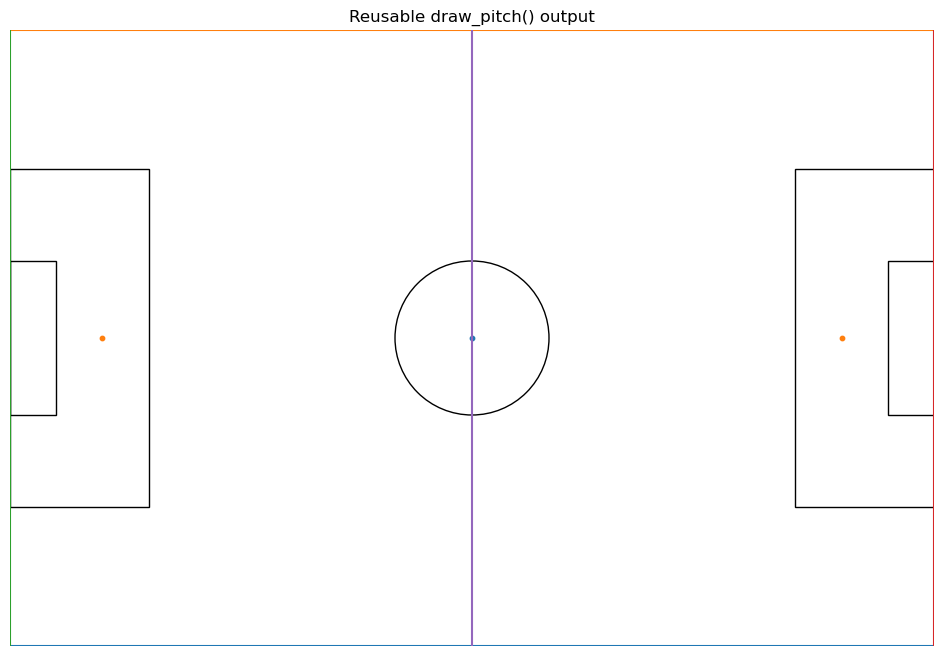

In [23]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

def extract_xy(location):
    if isinstance(location, (list, tuple)) and len(location) >= 2:
        return float(location[0]), float(location[1])
    return np.nan, np.nan

def draw_pitch(ax=None, figsize=(12, 8)):
    '''
    Draw a StatsBomb-style soccer pitch.
    StatsBomb coordinates are typically 120 by 80.
    '''
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    # Outer boundaries
    ax.plot([0, 120], [0, 0])
    ax.plot([0, 120], [80, 80])
    ax.plot([0, 0], [0, 80])
    ax.plot([120, 120], [0, 80])

    # Halfway line
    ax.plot([60, 60], [0, 80])

    # Center circle and spot
    ax.add_patch(Circle((60, 40), 10, fill=False))
    ax.scatter([60], [40], s=10)

    # Penalty boxes
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False))

    # Six-yard boxes
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False))

    # Penalty spots
    ax.scatter([12, 108], [40, 40], s=10)

    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig, ax

def get_possession_events(df, possession_id):
    '''Return all events belonging to one possession, ordered by period, minute, and second.'''
    return (
        df[df["possession"] == possession_id]
        .sort_values(["period", "minute", "second"])
        .reset_index(drop=True)
    )

def plot_events_on_pitch(events, title="Filtered events on pitch", show_labels=True, show_arrows=True):
    '''Plot a filtered event DataFrame on top of the pitch.'''
    plot_df = events.copy()
    xy = plot_df["location"].apply(extract_xy)
    plot_df["x"] = [v[0] for v in xy]
    plot_df["y"] = [v[1] for v in xy]
    plot_df = plot_df.dropna(subset=["x", "y"]).reset_index(drop=True)

    fig, ax = draw_pitch()

    ax.scatter(plot_df["x"], plot_df["y"], s=80)

    if show_arrows and len(plot_df) > 1:
        for i in range(len(plot_df) - 1):
            ax.annotate(
                "",
                xy=(plot_df.loc[i + 1, "x"], plot_df.loc[i + 1, "y"]),
                xytext=(plot_df.loc[i, "x"], plot_df.loc[i, "y"]),
                arrowprops=dict(arrowstyle="->", lw=1.5),
            )

    if show_labels:
        for i, row in plot_df.iterrows():
            label = f"{i+1}: {row['event_type']}"
            ax.text(row["x"] + 1, row["y"] + 1, label, fontsize=8)

    ax.set_title(title)
    plt.show()
    return fig, ax

# Quick check that the pitch draws correctly
fig, ax = draw_pitch()
ax.set_title("Reusable draw_pitch() output")
plt.show()


### 2(e) Identify and visualize one possession

The code below searches for a possession ending in a shot. If no shot exists, it chooses a possession with several events.


Chosen possession: 14
Team in possession: Argentina
Number of events: 5
Final event type: Goal Keeper


,team,player,period,minute,second,event_type,location
0,Argentina,Julián Álvarez,1,4,38,Pass,"[98.7, 19.8]"
1,Argentina,Alexis Mac Allister,1,4,39,Ball Receipt*,"[92.3, 21.5]"
2,Argentina,Alexis Mac Allister,1,4,39,Carry,"[92.3, 21.5]"
3,Argentina,Alexis Mac Allister,1,4,40,Shot,"[92.4, 30.0]"
4,France,Hugo Lloris,1,4,41,Goal Keeper,"[117.3, 38.4]"


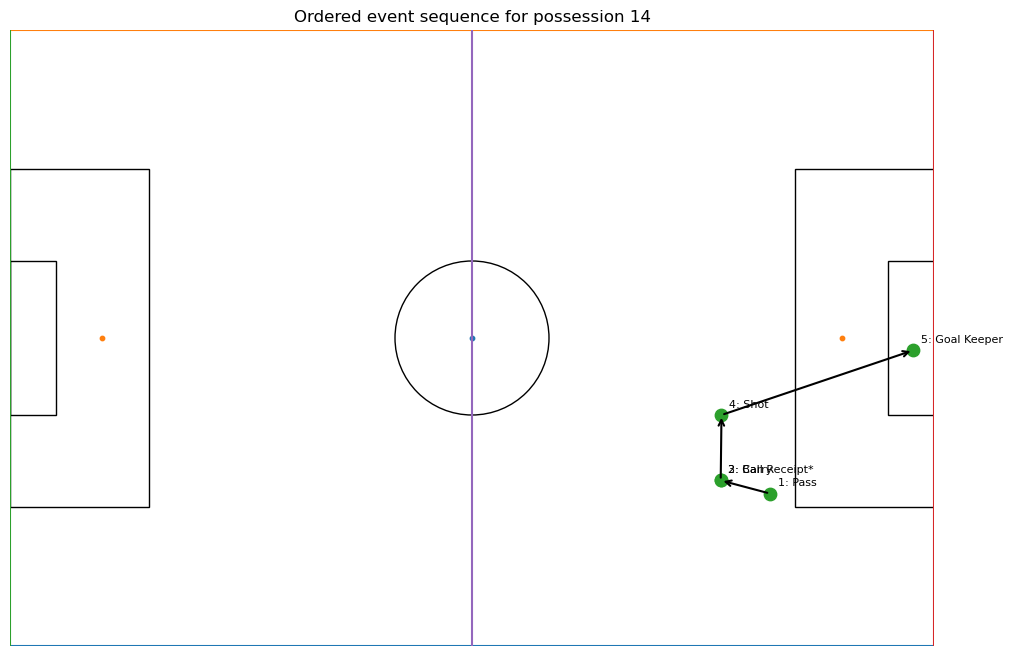

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Ordered event sequence for possession 14'}>)

In [25]:

REFERENCE_TEAM = "Argentina" 

def normalize_location(row):
    loc = row["location"]
    if not isinstance(loc, list) or len(loc) < 2:
        return loc
    if row["team"] == REFERENCE_TEAM:
        return [loc[0], loc[1]]
    return [120 - loc[0], 80 - loc[1]]

soccer["location"] = soccer.apply(normalize_location, axis=1)



shot_possessions = soccer.loc[soccer["event_type"].astype(str).str.contains("Shot", case=False, na=False), "possession"].dropna().unique()

if len(shot_possessions) > 0:
    chosen_possession = shot_possessions[0]
else:
    possession_sizes = soccer.groupby("possession").size().sort_values(ascending=False)
    chosen_possession = possession_sizes.index[0]

possession_events = get_possession_events(soccer, chosen_possession)

print("Chosen possession:", chosen_possession)
print("Team in possession:", possession_events["team"].mode().iloc[0])
print("Number of events:", len(possession_events))
print("Final event type:", possession_events["event_type"].iloc[-1])
display(possession_events[["team", "player", "period", "minute", "second", "event_type", "location"]])

plot_events_on_pitch(
    possession_events,
    title=f"Ordered event sequence for possession {chosen_possession}"
)


### 2(f) Possession write-up

The selected possession was controlled by the Argentina, more specifically it was Mac Allister. Only 4 events occured on this play, a pass from julain Alvarez, and a reception, dribble, and shot by Mac Allister, who found an opening to shoot and he took it. Ultimately, it was saved by Lloris, ending the possesion as France had the ball. Its useful to see where he dribbled the ball too, as he probably recieved the ball and immediately looked to get the best shooting position he could. 

## 3. Learning with AI

### 3(a) Concept selected

The concept I feel least prepared to explain fluently is model evaluation using probability based metrics, specifically log loss and Brier score. I chose this because it is easy for anyone to understand accuracy, but it is less obvious why two models with similar accuracy can have very different probability quality. Throughout these assignments I feel these concepts have given me the most trouble. 


### 3(b) Explanation at three levels

To a friend or family member:  
A model can be right or wrong, but it can also be more or less confident. Accuracy only checks whether the model picked the right winner. Log loss and Brier score check whether the model gave a good probability. So a model that says a team has a 55% chance to win is treated differently from a model that says 99%, even if both picked the same team.

To a classmate:
Accuracy evaluates hard classifications after applying a cutoff like 0.5. Brier score evaluates the squared error between the predicted probability and the actual binary outcome. Log loss evaluates probabilistic predictions more harshly, especially when the model is very confident and wrong. ROC-AUC measures whether the model ranks positive examples above negative examples.

More technical explanation:  
For a binary outcome, the Brier score is the mean squared difference between the predicted probability and the observed outcome. Log loss is the negative log-likelihood of the true labels under the predicted probabilities. These metrics are useful because sports prediction is often about calibrated probabilities, not only binary picks.


### 3(c) Example, misconception, and confusion

The obvious concrete sports example is a March Madness bracket prediction. If Duke is predicted to beat a 15 seed, a model might assign Duke a 95% win probability. If two evenly matched teams play, the model might assign one team a 52% win probability. Both predictions may select a winner, but the confidence levels mean very different things.

A common misconception is that a model with higher accuracy is always the better model. That is not always true, especially when the probabilities matter. And that is what these metrics are for. Log loss penalizes a prediction for being confidently wrong, making a 95% incorrect prediction worse than a 67% incorrect prediction. Brier Score measures how close the predicted probabilities are to reality, and ROC AUC looks at how well the model ranks teams overall. 

I think what confused me was not actually understanding what each metric did, I had a rough idea of ROC AUC and Log loss, but no idea about brier. 

### 3(e) Final reflection

I now understand that evaluation is not just about whether a model predicts the winner. In sports analytics, probabilities matter because they tell us how confident a model is. I alos understand more about the metrics behind this, and the only thing that feels missing now is that I need to use these metrics again now that I understand them better, to get more real practice with them. 